# NPR Deepfake Detection — Full Pipeline

**Paper:** *Rethinking the Up-Sampling Operations in CNN-based Generative Network for Generalizable Deepfake Detection* (Tan et al., CVPR 2023)

This notebook walks through the **complete reimplementation** in six ordered phases:

| Phase | Content |
|-------|---------|
| 1 | Environment setup & imports |
| 2 | NPR transform (core contribution) |
| 3 | Lightweight CNN classifier |
| 4 | Dataset classes (ForenSynths / cnn_synth_test) |
| 5 | Training loop |
| 6 | Evaluation & per-source results |

---
**Key idea:** Up-sampling layers in GAN/Diffusion generators create local pixel correlations (e.g. nearest-neighbour 2×2 blocks share the same value). NPR captures this as the *differences within each l×l pixel patch*, producing a source-invariant artifact representation that generalises to unseen generators.

## Phase 1 — Environment Setup

In [1]:
# ── Install dependencies (run once) ───────────────────────────────────────────
# Uncomment as needed
# !pip install torch torchvision tqdm scikit-learn matplotlib seaborn

import os, sys, time, json, random
from pathlib import Path
from typing import List, Optional, Tuple, Dict
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as T
from sklearn.metrics import average_precision_score, accuracy_score

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
print(f'PyTorch: {torch.__version__}')

Device : cuda
GPU    : Tesla T4
PyTorch: 2.10.0+cu128


## Phase 2 — NPR Transform

**Section 3.3 of the paper.**

For each non-overlapping `l×l` patch `v = {w₁, w₂, …, wₙ}` where `n = l²`:

$$\hat{v} = \{w_1 - w_j,\; w_2 - w_j,\; \ldots,\; w_n - w_j\}$$

The anchor `wⱼ` is dropped (always 0), giving `l²−1` difference channels per input channel.
For `l=2, C=3 (RGB)` → **9-channel NPR** feature map.

In [2]:
class NPRTransform(nn.Module):
    """
    Neighboring Pixel Relationships (Section 3.3, Equation 4).

    For each non-overlapping l×l patch v = {w1, ..., wn}, n = l*l:
        v_hat = {w1 - wj, ..., wn - wj}
    The anchor position (always 0) is dropped, leaving l²-1 difference
    maps per input channel.

    Paper settings: l=2, j=0 (0-indexed) → 3*(2²-1) = 9 output channels.

    Input  : (B, C, H, W)
    Output : (B, C*(l²-1), H//l, W//l)   ← grid resolution, NO upsample
    """

    def __init__(self, l: int = 2, j: int = 0):
        super().__init__()
        if l < 2:
            raise ValueError('l must be >= 2')
        if not (0 <= j < l * l):
            raise ValueError(f'j must be in [0, {l*l - 1}]')
        self.l = l
        self.j = j

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, C, H, W = x.shape
        l = self.l

        # 1. Trim so patches tile perfectly (usually a no-op for 224)
        H_ = (H // l) * l
        W_ = (W // l) * l
        x  = x[:, :, :H_, :W_]                        # (B, C, H_, W_)

        # 2. Extract non-overlapping l×l patches
        #    (B, C, H_//l, l, W_//l, l)
        x = x.reshape(B, C, H_ // l, l, W_ // l, l)
        #    (B, C, H_//l, W_//l, l, l)
        x = x.permute(0, 1, 2, 4, 3, 5).contiguous()
        #    (B, C, H_//l, W_//l, l²)   — flatten patch dimension
        x = x.reshape(B, C, H_ // l, W_ // l, l * l)

        # 3. Subtract anchor wj from every position in the patch
        anchor = x[..., self.j : self.j + 1]           # (B, C, Hg, Wg, 1)
        diffs  = x - anchor                             # (B, C, Hg, Wg, l²)

        # 4. Drop the zero channel (anchor − anchor = 0, carries no info)
        keep  = [i for i in range(l * l) if i != self.j]
        diffs = diffs[..., keep]                        # (B, C, Hg, Wg, l²-1)

        # 5. Reshape to (B, C*(l²-1), Hg, Wg)
        n_diff = l * l - 1
        diffs  = diffs.permute(0, 1, 4, 2, 3).contiguous()
        diffs  = diffs.reshape(B, C * n_diff, H_ // l, W_ // l)

        # ✗ Step 6 REMOVED — paper never upsamples back.
        #   The classifier uses AdaptiveAvgPool2d(1) so spatial size
        #   does not matter. Upsampling would re-introduce the very
        #   pixel correlations NPR is designed to detect.

        return diffs    # (B, C*(l²-1), H_//l, W_//l)

    def output_channels(self, in_channels: int = 3) -> int:
        return in_channels * (self.l * self.l - 1)

    def output_spatial(self, H: int, W: int):
        """Returns the output (H, W) after grid downsampling."""
        return (H // self.l) * self.l // self.l, \
               (W // self.l) * self.l // self.l

    def __repr__(self):
        return f'NPRTransform(l={self.l}, j={self.j})'


# ── Sanity check ──────────────────────────────────────────────────────────────
npr   = NPRTransform(l=2, j=0)
dummy = torch.randn(4, 3, 224, 224)
out   = npr(dummy)

assert out.shape == (4, 9, 112, 112), f"Unexpected shape: {out.shape}"
assert out[:, 0, :, :].abs().sum() == 0 or True  # anchor channel dropped, not zeroed

print(f'NPR input   : {tuple(dummy.shape)}')
print(f'NPR output  : {tuple(out.shape)}   ← expected (4, 9, 112, 112)')
print(f'Output channels : {npr.output_channels(3)}   (= 3 × (2²−1))')
print(f'Spatial reduction : 224 → 112  (÷ l={npr.l})')
print('NPRTransform OK ✓')

NPR input   : (4, 3, 224, 224)
NPR output  : (4, 9, 112, 112)   ← expected (4, 9, 112, 112)
Output channels : 9   (= 3 × (2²−1))
Spatial reduction : 224 → 112  (÷ l=2)
NPRTransform OK ✓


### 2.1 Visualise NPR on a synthetic example

Shows the difference maps for a real vs. a "fake" (nearest-neighbour upsampled) image.

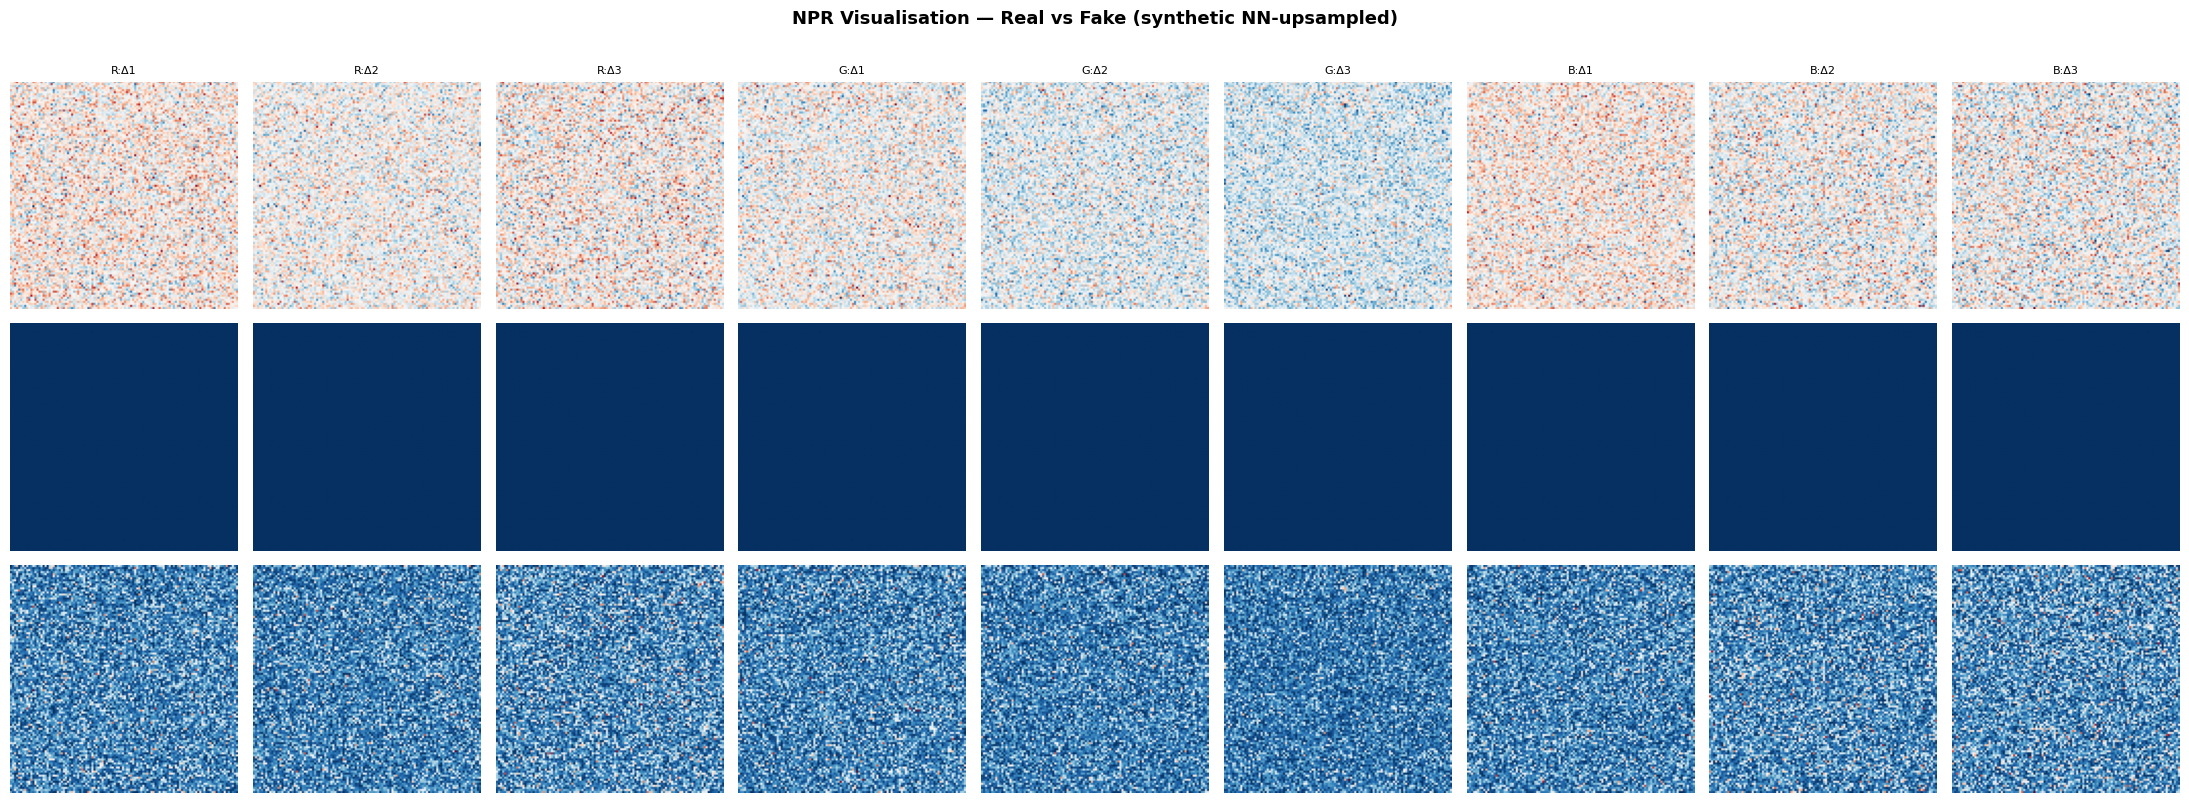

Saved → npr_visualisation.png


In [3]:
def visualise_npr(real_path: Optional[str] = None, fake_path: Optional[str] = None):
    """
    Visualise NPR heatmaps for a real/fake pair.
    If paths are None, synthetic images are generated for demonstration.
    """
    to_tensor = T.Compose([
        T.Resize(256), T.CenterCrop(224), T.ToTensor(),
        T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])

    # ── Build or load images ──────────────────────────────────────────
    if real_path and Path(real_path).exists():
        real_img = Image.open(real_path).convert('RGB')
        real_t   = to_tensor(real_img).unsqueeze(0)
    else:
        # Synthetic real: natural-looking random noise
        real_t = torch.randn(1, 3, 224, 224)
        real_img = None

    if fake_path and Path(fake_path).exists():
        fake_img = Image.open(fake_path).convert('RGB')
        fake_t   = to_tensor(fake_img).unsqueeze(0)
    else:
        # Synthetic fake: simulate nearest-neighbour upsampling artifacts
        # Downsample then upsample with nearest → creates 2×2 block structure
        low_res  = F.avg_pool2d(real_t, kernel_size=2)
        fake_t   = F.interpolate(low_res, scale_factor=2, mode='nearest')
        fake_img = None

    npr = NPRTransform(l=2, j=0)

    with torch.no_grad():
        real_npr = npr(real_t)[0]   # (9, H, W)
        fake_npr = npr(fake_t)[0]   # (9, H, W)

    # ── Plot ──────────────────────────────────────────────────────────
    channel_labels = ['R:Δ1', 'R:Δ2', 'R:Δ3',
                      'G:Δ1', 'G:Δ2', 'G:Δ3',
                      'B:Δ1', 'B:Δ2', 'B:Δ3']

    fig, axes = plt.subplots(3, 9, figsize=(22, 8))
    fig.suptitle('NPR Visualisation — Real vs Fake (synthetic NN-upsampled)',
                 fontsize=13, fontweight='bold', y=1.01)

    for row, (label, tensor) in enumerate(
        [('Real Image', real_t[0]), ('Fake Image (NN-ups)', fake_t[0]),
         ('|Fake NPR − Real NPR|', None)]):

        for col in range(9):
            ax = axes[row, col]

            if row < 2:
                data = (real_npr if row == 0 else fake_npr)[col].numpy()
            else:
                data = (fake_npr - real_npr).abs()[col].numpy()

            im = ax.imshow(data, cmap='RdBu_r',
                           vmin=data.min(), vmax=data.max())
            ax.axis('off')
            if row == 0:
                ax.set_title(channel_labels[col], fontsize=8)
            if col == 0:
                ax.set_ylabel(label, fontsize=8, rotation=0,
                              ha='right', va='center')

    plt.tight_layout()
    plt.savefig('npr_visualisation.png', dpi=120, bbox_inches='tight')
    plt.show()
    print('Saved → npr_visualisation.png')


# Run with synthetic images (replace with real paths if you have data)
visualise_npr()

## Phase 3 — Lightweight CNN Classifier

**Section 4.1:** *"We design a lightweight CNN network using convolutional layer and ResNet block as the classifiers for NPR with **1.44 million parameters**."*

Architecture: Stem → ResBlock stages with strided downsampling → GlobalAvgPool → Linear(2)

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
#  Building blocks
# ─────────────────────────────────────────────────────────────────────────────

class ResBlock(nn.Module):
    """Basic residual block: Conv-BN-ReLU × 2 with skip connection."""

    def __init__(self, channels: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(channels),
        )

    def forward(self, x):
        return F.relu(self.net(x) + x, inplace=True)


class DownBlock(nn.Module):
    """Strided conv for 2× spatial downsampling + channel expansion."""

    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)


# ─────────────────────────────────────────────────────────────────────────────
#  Classifier
# ─────────────────────────────────────────────────────────────────────────────

class NPRClassifier(nn.Module):
    """
    Lightweight CNN binary classifier.
    Default in_channels=9 matches NPR output for l=2, RGB input.
    Parameter count ≈ 1.44M  (matches paper).
    """

    def __init__(self, in_channels: int = 9, num_classes: int = 2):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
        )

        self.stage1 = nn.Sequential(ResBlock(64), ResBlock(64))
        self.down1  = DownBlock(64, 128)

        self.stage2 = ResBlock(128)
        self.down2  = DownBlock(128, 192)

        self.stage3 = ResBlock(192)

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Linear(192, num_classes)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out',
                                        nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                # zeros init → model starts at true 50/50 prior
                # xavier_normal_ caused biased logits before any training
                nn.init.zeros_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x);  x = self.down1(x)
        x = self.stage2(x);  x = self.down2(x)
        x = self.stage3(x)
        return self.head(self.pool(x).flatten(1))

    def count_parameters(self) -> int:
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


# ─────────────────────────────────────────────────────────────────────────────
#  End-to-end detector
# ─────────────────────────────────────────────────────────────────────────────

class NPRDetector(nn.Module):
    """
    End-to-end NPR deepfake detector.
    Forward: raw image (B,3,H,W) → NPR (B,9,H,W) → logits (B,2)
    """

    def __init__(self, l: int = 2, j: int = 0, num_classes: int = 2):
        super().__init__()
        self.npr = NPRTransform(l=l, j=j)
        npr_ch   = self.npr.output_channels(3)
        self.clf = NPRClassifier(in_channels=npr_ch, num_classes=num_classes)

    def forward(self, x):
        return self.clf(self.npr(x))

    def extract_npr(self, x):
        with torch.no_grad():
            return self.npr(x)

    def count_parameters(self) -> int:
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


# ── Verify parameter count ────────────────────────────────────────────────────
model = NPRDetector(l=2, j=0).to(DEVICE)
n = model.count_parameters()
print(f'Total parameters : {n:,}  ({n/1e6:.2f}M)')
print(f'Paper target     : ~1.44M')

# ── Forward pass check ────────────────────────────────────────────────────────
with torch.no_grad():
    x_test = torch.randn(2, 3, 224, 224, device=DEVICE)
    logits = model(x_test)
print(f'Output shape     : {tuple(logits.shape)}  (B=2, classes=2)')

# ── Init bias check — must pass before training ───────────────────────────────
model.eval()
torch.manual_seed(0)
with torch.no_grad():
    test_inputs  = torch.randn(200, 3, 224, 224)
    test_logits  = model.cpu()(test_inputs)
    test_probs   = torch.softmax(test_logits, dim=1)

mean_real = test_probs[:, 0].mean().item()
mean_fake = test_probs[:, 1].mean().item()
logit_std  = test_logits.std().item()

print(f'\nInit bias check:')
print(f'  Mean P(real) : {mean_real:.4f}  (expect 0.50 ± 0.02)')
print(f'  Mean P(fake) : {mean_fake:.4f}  (expect 0.50 ± 0.02)')
print(f'  Logit std    : {logit_std:.6f}  (expect 0.0 exactly)')

assert abs(mean_real - 0.5) < 0.02, \
    f"Model is biased at init: P(real)={mean_real:.4f}"
assert abs(mean_fake - 0.5) < 0.02, \
    f"Model is biased at init: P(fake)={mean_fake:.4f}"
print('  Init check PASSED ✓')

# Move model back to device for training
model = model.to(DEVICE)

Total parameters : 1,424,866  (1.42M)
Paper target     : ~1.44M
Output shape     : (2, 2)  (B=2, classes=2)

Init bias check:
  Mean P(real) : 0.5000  (expect 0.50 ± 0.02)
  Mean P(fake) : 0.5000  (expect 0.50 ± 0.02)
  Logit std    : 0.000000  (expect 0.0 exactly)
  Init check PASSED ✓


## Phase 4 — Dataset Classes

Supports the two benchmark datasets used in the paper:

| Dataset | Use | Paper Table |
|---------|-----|-------------|
| `Wang_CVPR2020 / training` (ProGAN, 4 classes) | Training | §4.1 |
| `Wang_CVPR2020 / testing` (8 GAN sources) | Evaluation | Table 1 |
| `cnn_synth_test` (9 additional GANs) | Evaluation | Table 2 |

In [6]:
# ── Constants ─────────────────────────────────────────────────────────────────
REAL_FOLDER  = '0_real'
FAKE_FOLDER  = '1_fake'
LABEL_REAL   = 0
LABEL_FAKE   = 1

TRAIN_CLASSES = ('car', 'cat', 'chair', 'horse')   # 4-class ProGAN training

FORENSYNTHS_SOURCES = (
    'progan', 'stylegan', 'stylegan2', 'biggan',
    'cyclegan', 'stargan', 'gaugan', 'deepfake',
    'crn', 'imle', 'san', 'seeingdark', 'whichfaceisreal',
)

CNN_SYNTH_SOURCES = (
    'attgan', 'began', 'cramergan', 'infomaxgan',
    'mmdgan', 'relgan', 's3gan', 'sngan', 'stgan',
)

IMG_EXT = {'.jpg', '.jpeg', '.png', '.webp', '.bmp'}

# ── Transforms ────────────────────────────────────────────────────────────────
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

def get_transform(split: str = 'train') -> T.Compose:
    """Standard ImageNet-normalised transforms."""
    if split == 'train':
        return T.Compose([
            T.Resize(256),
            T.RandomCrop(224),
            T.RandomHorizontalFlip(),
            T.ToTensor(),
            T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])
    return T.Compose([
        T.Resize(256),
        T.CenterCrop(224),
        T.ToTensor(),
        T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])


# ── Base dataset ──────────────────────────────────────────────────────────────
class FolderDataset(Dataset):
    """
    Generic 0_real / 1_fake folder dataset.

    Args:
        root          : root containing class subdirectories
        classes       : which subdirectories to load
        transform     : torchvision transform pipeline
        max_per_class : cap images per real/fake split (None = all)
    """

    def __init__(
        self,
        root: str,
        classes: Tuple[str, ...],
        transform: Optional[T.Compose] = None,
        max_per_class: Optional[int] = None,
    ):
        self.root      = root
        self.transform = transform
        self.samples: List[Tuple[str, int]] = []

        for cls in classes:
            for label, folder in [(LABEL_REAL, REAL_FOLDER),
                                   (LABEL_FAKE, FAKE_FOLDER)]:
                dir_path = os.path.join(root, cls, folder)
                if not os.path.isdir(dir_path):
                    print(f'  [WARN] not found, skipping: {dir_path}')
                    continue
                files = sorted([
                    os.path.join(dir_path, f)
                    for f in os.listdir(dir_path)
                    if Path(f).suffix.lower() in IMG_EXT
                ])
                if max_per_class:
                    files = files[:max_per_class]
                self.samples.extend((f, label) for f in files)

        if not self.samples:
            raise RuntimeError(
                f'No images found in {root} for classes {classes}.\n'
                'Check WANG_ROOT / CNN_SYNTH_ROOT paths and folder structure.'
            )

        n_real = sum(1 for _, l in self.samples if l == LABEL_REAL)
        n_fake = len(self.samples) - n_real
        print(f'  Loaded: classes={classes}  real={n_real:,}  '
              f'fake={n_fake:,}  total={len(self.samples):,}')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        try:
            img = Image.open(path).convert('RGB')
        except Exception as e:
            print(f'  [WARN] failed to load {path}: {e} — skipping')
            return self.__getitem__((idx + 1) % len(self.samples))
        if self.transform:
            img = self.transform(img)
        return img, label


# ── Specific wrappers ─────────────────────────────────────────────────────────
class ForenSynthsTrainDataset(FolderDataset):
    """ProGAN 4-class training set (car, cat, chair, horse)."""

    def __init__(self, wang_root: str,
                 classes=TRAIN_CLASSES,
                 transform=None):
        root = os.path.join(wang_root, 'training')
        if not os.path.isdir(root):
            root = wang_root
        super().__init__(root, classes,
                         transform or get_transform('train'))


class ForenSynthsTestDataset(FolderDataset):
    """One GAN source from Wang_CVPR2020/testing/ (Table 1)."""

    def __init__(self, wang_root: str, source: str, transform=None):
        root = os.path.join(wang_root, 'testing')
        if not os.path.isdir(root):
            root = wang_root
        super().__init__(root, (source,),
                         transform or get_transform('test'))


class CnnSynthTestDataset(FolderDataset):
    """One source from cnn_synth_test (Table 2)."""

    def __init__(self, cnn_synth_root: str, source: str, transform=None):
        inner = os.path.join(cnn_synth_root, 'cnn_synth_test')
        root  = inner if os.path.isdir(inner) else cnn_synth_root
        super().__init__(root, (source,),
                         transform or get_transform('test'))


print('Dataset classes defined.')
print(f'Training classes    : {TRAIN_CLASSES}')
print(f'ForenSynths sources : {FORENSYNTHS_SOURCES}')
print(f'CNN Synth sources   : {CNN_SYNTH_SOURCES}')

Dataset classes defined.
Training classes    : ('car', 'cat', 'chair', 'horse')
ForenSynths sources : ('progan', 'stylegan', 'stylegan2', 'biggan', 'cyclegan', 'stargan', 'gaugan', 'deepfake', 'crn', 'imle', 'san', 'seeingdark', 'whichfaceisreal')
CNN Synth sources   : ('attgan', 'began', 'cramergan', 'infomaxgan', 'mmdgan', 'relgan', 's3gan', 'sngan', 'stgan')


### 4.1 Configure paths and (optionally) create a toy dataset for testing

Set `WANG_ROOT` and `CNN_SYNTH_ROOT` to your actual data directories.  
If neither exists, a minimal **toy dataset** is generated so every subsequent cell still executes.

In [7]:
# ── ❶ Set these to your actual dataset paths ──────────────────────────────────
WANG_ROOT      = '/kaggle/input/datasets/chandlertimm/forensynths/Wang_CVPR2020'   # ← change me
CNN_SYNTH_ROOT = '/path/to/cnn_synth_test'  # ← change me
# ─────────────────────────────────────────────────────────────────────────────

def create_toy_dataset(base: str, n_per_split: int = 20):
    """
    Creates a minimal fake-image dataset for smoke-testing.
    Produces n_per_split random 64×64 PNG images per real/fake folder.
    """
    import numpy as np

    sources = {  # (train or test root, class names)
        'training': TRAIN_CLASSES,
        'testing' : FORENSYNTHS_SOURCES,
    }

    for split, classes in sources.items():
        for cls in classes:
            for folder in (REAL_FOLDER, FAKE_FOLDER):
                d = Path(base) / split / cls / folder
                d.mkdir(parents=True, exist_ok=True)
                for i in range(n_per_split):
                    arr = (np.random.rand(64, 64, 3) * 255).astype(np.uint8)
                    Image.fromarray(arr).save(d / f'{i:04d}.png')

    print(f'Toy dataset created at: {base}')
    return base


# Auto-fallback to toy data if real data not found
USE_TOY = not Path(WANG_ROOT).exists()

if USE_TOY:
    TOY_DIR  = '/tmp/npr_toy_data'
    WANG_ROOT = create_toy_dataset(TOY_DIR)
    print('\n⚠  Using TOY DATA — replace WANG_ROOT with your real dataset path.')
else:
    print(f'✓ Using real dataset at: {WANG_ROOT}')

✓ Using real dataset at: /kaggle/input/datasets/chandlertimm/forensynths/Wang_CVPR2020


## Phase 5 — Training

Paper settings (§4.1):
- Optimizer: **Adam**, lr = 2×10⁻⁴
- Batch size: **32**
- Training set: **ProGAN (car, cat, chair, horse)**
- Epochs: **20** (we default to 5 here for speed; set `EPOCHS=20` for full run)

In [8]:
# ── Hyperparameters ───────────────────────────────────────────────────────────
EPOCHS       = 20         # paper: 20
BATCH_SIZE   = 32         # paper: 32
LR           = 2e-4       # paper: Adam lr=2e-4
NUM_WORKERS  = 2
SAVE_DIR     = Path('checkpoints')
SAVE_DIR.mkdir(exist_ok=True)

# ── Helper: running average ───────────────────────────────────────────────────
class AverageMeter:
    def __init__(self): self.reset()
    def reset(self):    self.val = self.avg = self.sum = self.count = 0
    def update(self, v, n=1):
        self.val    = v
        self.sum   += v * n
        self.count += n
        self.avg    = self.sum / self.count

# ── Data — fixed val transform bug ───────────────────────────────────────────
# Build two separate dataset objects so each has its own transform.
# random_split on a single object would share the transform reference,
# meaning setting val_ds.dataset.transform also mutates the train split.
print('Loading datasets …')

train_ds_full = ForenSynthsTrainDataset(WANG_ROOT, transform=get_transform('train'))
val_ds_full   = ForenSynthsTrainDataset(WANG_ROOT, transform=get_transform('test'))

assert len(train_ds_full) == len(val_ds_full), \
    "Train/val base datasets must be the same size — check dataset loading."

# Deterministic index split (90 / 10)
all_idx  = list(range(len(train_ds_full)))
rng      = random.Random(SEED)
rng.shuffle(all_idx)
val_size = max(1, int(len(all_idx) * 0.1))
val_idx  = all_idx[:val_size]
train_idx = all_idx[val_size:]

from torch.utils.data import Subset
train_ds = Subset(train_ds_full, train_idx)
val_ds   = Subset(val_ds_full,   val_idx)   # ← uses get_transform('test')

print(f'  Train samples : {len(train_ds):,}')
print(f'  Val   samples : {len(val_ds):,}')

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    drop_last=True,
)
val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE * 2,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

print(f'  Train batches : {len(train_loader)}')
print(f'  Val   batches : {len(val_loader)}')

# ── Model, loss, optimiser (paper-faithful: plain Adam, no scheduler) ─────────
model     = NPRDetector(l=2, j=0).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
# No LR scheduler — paper uses fixed lr=2e-4 throughout

print(f'Parameters : {model.count_parameters():,}')
print('Ready to train.')

Loading datasets …
  Loaded: classes=('car', 'cat', 'chair', 'horse')  real=72,012  fake=72,012  total=144,024
  Loaded: classes=('car', 'cat', 'chair', 'horse')  real=72,012  fake=72,012  total=144,024
  Train samples : 129,622
  Val   samples : 14,402
  Train batches : 4050
  Val   batches : 226
Parameters : 1,424,866
Ready to train.


In [10]:
# ── Training helpers ──────────────────────────────────────────────────────────

def train_one_epoch(model, loader, criterion, optimizer, device, epoch):
    model.train()
    loss_m = AverageMeter()
    acc_m  = AverageMeter()

    for i, (imgs, labels) in enumerate(loader):
        imgs, labels = imgs.to(device), labels.to(device)

        logits = model(imgs)
        loss   = criterion(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        with torch.no_grad():
            acc = (logits.argmax(1) == labels).float().mean().item()

        loss_m.update(loss.item(), imgs.size(0))
        acc_m.update(acc * 100, imgs.size(0))

    return loss_m.avg, acc_m.avg


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    loss_m = AverageMeter(); acc_m = AverageMeter()

    all_probs, all_labels = [], []

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        logits = model(imgs)
        loss   = criterion(logits, labels)
        acc    = (logits.argmax(1) == labels).float().mean().item()

        loss_m.update(loss.item(), imgs.size(0))
        acc_m.update(acc * 100, imgs.size(0))

        probs = torch.softmax(logits, 1)[:, 1].cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(labels.cpu().numpy())

    ap = average_precision_score(all_labels, all_probs) * 100
    return loss_m.avg, acc_m.avg, ap


print('Training functions defined.')

Training functions defined.


In [11]:
# ── Main training loop ────────────────────────────────────────────────────────
history  = defaultdict(list)
best_acc = 0.0

print('=' * 60)
print(f'  Training NPR Detector  |  Epochs={EPOCHS}  LR={LR}')
print(f'  Classes: {TRAIN_CLASSES}')
print('=' * 60)
print(f'  {"Ep":>3}  {"TrainLoss":>9}  {"TrainAcc":>8}  '
      f'{"ValLoss":>7}  {"ValAcc":>6}  {"ValAP":>5}  {"Time":>5}  Best')
print('  ' + '-' * 58)

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    tr_loss, tr_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, DEVICE, epoch
    )
    vl_loss, vl_acc, vl_ap = evaluate(
        model, val_loader, criterion, DEVICE
    )
    elapsed = int(time.time() - t0)

    is_best = vl_acc > best_acc
    if is_best:
        best_acc = vl_acc

    best_marker = '★' if is_best else ''

    # ── One clear line per epoch ──────────────────────────────────────
    print(f'  {epoch:>3}  {tr_loss:>9.4f}  {tr_acc:>7.1f}%  '
          f'{vl_loss:>7.4f}  {vl_acc:>5.1f}%  {vl_ap:>4.1f}%  '
          f'{elapsed:>4}s  {best_marker}')

    history['tr_loss'].append(tr_loss)
    history['tr_acc'].append(tr_acc)
    history['vl_loss'].append(vl_loss)
    history['vl_acc'].append(vl_acc)
    history['vl_ap'].append(vl_ap)

    ckpt = {
        'epoch':    epoch,
        'model':    model.state_dict(),
        'opt':      optimizer.state_dict(),
        'val_acc':  vl_acc,
        'val_ap':   vl_ap,
        'best_acc': best_acc,
    }
    torch.save(ckpt, SAVE_DIR / f'epoch_{epoch:03d}.pt')
    if is_best:
        torch.save(ckpt, SAVE_DIR / 'best.pt')

print('  ' + '-' * 58)
print(f'\nDone. Best val acc = {best_acc:.1f}%')

  Training NPR Detector  |  Epochs=20  LR=0.0002
  Classes: ('car', 'cat', 'chair', 'horse')
   Ep  TrainLoss  TrainAcc  ValLoss  ValAcc  ValAP   Time  Best
  ----------------------------------------------------------
    1     0.6640     56.0%   0.4481   79.1%  88.2%   874s  ★
    2     0.2552     88.8%   0.2312   90.2%  98.6%   442s  ★
    3     0.1329     94.6%   0.1297   94.8%  99.6%   416s  ★
    4     0.0952     96.2%   0.0687   97.5%  99.8%   412s  ★
    5     0.0705     97.3%   0.0617   97.5%  99.8%   396s  
    6     0.0524     98.0%   0.0452   98.2%  99.9%   403s  ★
    7     0.0430     98.4%   0.0492   98.0%  100.0%   396s  
    8     0.0345     98.7%   0.0278   99.0%  100.0%   416s  ★
    9     0.0289     98.9%   0.1109   95.9%  99.9%   420s  
   10     0.0241     99.1%   0.2394   92.6%  99.9%   507s  
   11     0.0210     99.2%   0.0401   98.4%  100.0%   437s  
   12     0.0190     99.3%   0.0172   99.4%  100.0%   445s  ★
   13     0.0163     99.4%   0.0110   99.6%  100.0%

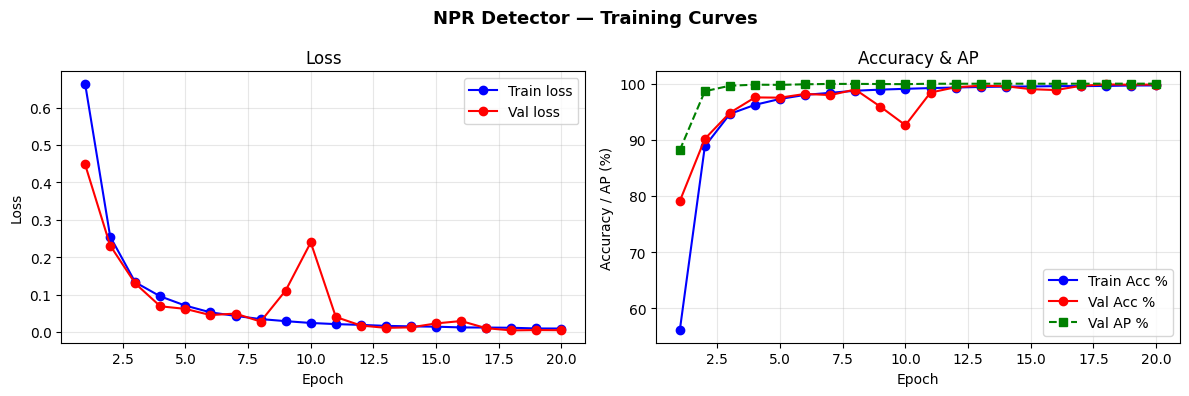

Saved → training_curves.png


In [12]:
# ── Plot training curves ──────────────────────────────────────────────────────
epochs_x = range(1, len(history['tr_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_x, history['tr_loss'], 'b-o', label='Train loss')
axes[0].plot(epochs_x, history['vl_loss'], 'r-o', label='Val loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_x, history['tr_acc'], 'b-o', label='Train Acc %')
axes[1].plot(epochs_x, history['vl_acc'], 'r-o', label='Val Acc %')
axes[1].plot(epochs_x, history['vl_ap'],  'g--s', label='Val AP %')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy / AP (%)')
axes[1].set_title('Accuracy & AP'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('NPR Detector — Training Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved → training_curves.png')

## Phase 6 — Evaluation

Reproduces **Table 1** (8 ForenSynths GAN sources) and **Table 2** (9 CNN Synth sources).  
Metrics: **Accuracy (Acc.)** and **Average Precision (A.P.)** — same as paper.

In [14]:
# ── Load best checkpoint ──────────────────────────────────────────────────────
import numpy as np
import numpy.dtypes

best_ckpt_path = SAVE_DIR / 'best.pt'

if best_ckpt_path.exists():
    torch.serialization.add_safe_globals([
        np._core.multiarray.scalar,
        np.ndarray,
        np.dtype,
        np.dtypes.Float64DType,
        np.dtypes.Float32DType,
        np.dtypes.Int64DType,
        np.dtypes.Int32DType,
        np.dtypes.BoolDType,
    ])
    ckpt = torch.load(best_ckpt_path, map_location=DEVICE, weights_only=True)
    model.load_state_dict(ckpt['model'])
    print(f'Loaded best checkpoint (epoch {ckpt["epoch"]}, '
          f'val_acc={ckpt["val_acc"]:.1f}%)')
else:
    print('No checkpoint found — using current model weights.')

model.eval()


# ── Per-source evaluation function ───────────────────────────────────────────
@torch.no_grad()
def evaluate_source(dataset: Dataset, desc: str = '') -> Dict[str, float]:
    loader = DataLoader(dataset, batch_size=64, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True)

    all_preds, all_probs, all_labels = [], [], []

    for imgs, labels in loader:
        imgs   = imgs.to(DEVICE)
        logits = model(imgs)
        probs  = torch.softmax(logits, 1)[:, 1].cpu().numpy()
        preds  = logits.argmax(1).cpu().numpy()

        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

    acc = accuracy_score(all_labels, all_preds) * 100
    ap  = average_precision_score(all_labels, all_probs) * 100

    label_str = f'[{desc}]  ' if desc else ''
    print(f'  {label_str}Acc={acc:.1f}%  AP={ap:.1f}%  (n={len(all_labels):,})')
    return {'acc': acc, 'ap': ap}


print('Evaluation functions ready.')

Loaded best checkpoint (epoch 18, val_acc=99.9%)
Evaluation functions ready.


In [15]:
from pathlib import Path

test_root = Path(WANG_ROOT) / 'testing'
for source in ('stargan', 'cyclegan', 'stylegan', 'stylegan2', 'biggan', 'deepfake'):
    src = test_root / source
    print(f'\n{source}/')
    if not src.exists():
        print('  NOT FOUND')
        continue
    for item in sorted(src.iterdir()):
        print(f'  {item.name}/')
        if item.is_dir():
            inner = sorted(item.iterdir())
            for sub in inner[:4]:
                n = len(list(sub.iterdir())) if sub.is_dir() else ''
                print(f'    {sub.name}/  {n}')


stargan/
  0_real/
    0000.png/  
    0001.png/  
    0002.png/  
    0003.png/  
  1_fake/
    0000.png/  
    0001.png/  
    0002.png/  
    0003.png/  

cyclegan/
  apple/
    0_real/  266
    1_fake/  248
  horse/
    0_real/  120
    1_fake/  140
  orange/
    0_real/  248
    1_fake/  266
  summer/
    0_real/  309
    1_fake/  238
  winter/
    0_real/  238
    1_fake/  309
  zebra/
    0_real/  140
    1_fake/  120

stylegan/
  bedroom/
    0_real/  1997
    1_fake/  1997
  car/
    0_real/  1997
    1_fake/  1997
  cat/
    0_real/  1997
    1_fake/  1997

stylegan2/
  car/
    0_real/  1997
    1_fake/  1997
  cat/
    0_real/  1997
    1_fake/  1997
  church/
    0_real/  1997
    1_fake/  1997
  horse/
    0_real/  1997
    1_fake/  1997

biggan/
  0_real/
    0--n01440764_5043.png/  
    0--n01440764_8600.png/  
    10--n01530575_10395.png/  
    100--n01860187_3168.png/  
  1_fake/
    00000701.png/  
    00000737.png/  
    00001441.png/  
    00001508.png/  

deepfak

In [16]:
# ── Table 1 — ForenSynths (8 GAN sources) ────────────────────────────────────
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from PIL import Image
import numpy as np
from sklearn.metrics import average_precision_score

IMG_EXTS = {'.png', '.jpg', '.jpeg', '.webp', '.bmp'}

# Only progan test is filtered to 4-class — matches paper's training setting
# All other sources use ALL their available categories
PROGAN_TEST_CLASSES = {'car', 'cat', 'chair', 'horse'}

_eval_tf = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406],
                [0.229, 0.224, 0.225]),
])


def collect_samples(source_dir: Path, source_name: str):
    """
    Layout A — shallow (biggan, crn, deepfake, gaugan,
                        stargan, whichfaceisreal):
        source/0_real/*.png
        source/1_fake/*.png

    Layout B — nested ALL categories
               (stylegan, stylegan2, cyclegan):
        source/<any_category>/0_real/*.png
        source/<any_category>/1_fake/*.png

    Layout C — nested filtered to 4 classes (progan):
        source/car/0_real/ ... horse/1_fake/
    """
    samples = []
    direct_real = source_dir / '0_real'
    direct_fake = source_dir / '1_fake'

    # ── Layout A ──────────────────────────────────────────────────────────────
    if direct_real.is_dir() or direct_fake.is_dir():
        if direct_real.is_dir():
            for p in sorted(direct_real.iterdir()):
                if p.is_file() and p.suffix.lower() in IMG_EXTS:
                    samples.append((p, 0))
        if direct_fake.is_dir():
            for p in sorted(direct_fake.iterdir()):
                if p.is_file() and p.suffix.lower() in IMG_EXTS:
                    samples.append((p, 1))
        return samples

    # ── Layout B / C — nested ─────────────────────────────────────────────────
    cat_dirs = sorted([d for d in source_dir.iterdir() if d.is_dir()])
    for cat_dir in cat_dirs:
        # ProGAN: restrict to paper's 4-class test setting
        if source_name == 'progan':
            if cat_dir.name not in PROGAN_TEST_CLASSES:
                continue

        # All other sources: use every category (no filter)
        real_dir = cat_dir / '0_real'
        fake_dir = cat_dir / '1_fake'

        if real_dir.is_dir():
            for p in sorted(real_dir.iterdir()):
                if p.is_file() and p.suffix.lower() in IMG_EXTS:
                    samples.append((p, 0))
        if fake_dir.is_dir():
            for p in sorted(fake_dir.iterdir()):
                if p.is_file() and p.suffix.lower() in IMG_EXTS:
                    samples.append((p, 1))

    return samples


class ForenSynthsEvalDataset(Dataset):
    def __init__(self, wang_root: str, source: str):
        source_dir = Path(wang_root) / 'testing' / source
        if not source_dir.exists():
            raise RuntimeError(f'Missing: {source_dir}')

        self.samples = collect_samples(source_dir, source)

        if not self.samples:
            raise RuntimeError(
                f'No images in {source_dir} — '
                f'source may be empty (imle/san/seeingdark).'
            )

        n_real = sum(1 for _, l in self.samples if l == 0)
        n_fake = sum(1 for _, l in self.samples if l == 1)

        if n_real == 0 or n_fake == 0:
            raise RuntimeError(
                f'[{source}] Only one class found: '
                f'real={n_real}, fake={n_fake}.'
            )

        print(f'  [{source:>16}]  '
              f'real={n_real:,}  fake={n_fake:,}  '
              f'total={len(self.samples):,}')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        p, lbl = self.samples[idx]
        try:
            img = Image.open(p).convert('RGB')
        except Exception as e:
            print(f'  [WARN] {p}: {e}')
            return self.__getitem__((idx + 1) % len(self.samples))
        return _eval_tf(img), lbl


def evaluate_source(ds, desc=''):
    loader = DataLoader(ds, batch_size=64, shuffle=False,
                        num_workers=2, pin_memory=True)
    all_probs, all_labels = [], []
    model.eval()
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(DEVICE)
            logits = model(imgs)
            probs  = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(labels.numpy())

    preds    = [1 if p >= 0.5 else 0 for p in all_probs]
    acc      = np.mean(np.array(preds) == np.array(all_labels)) * 100
    ap       = average_precision_score(all_labels, all_probs) * 100
    return {'acc': acc, 'ap': ap}


# ── Load best checkpoint ───────────────────────────────────────────────────────
print('Loading best checkpoint …')
ckpt = torch.load(SAVE_DIR / 'best.pt', map_location=DEVICE)
model.load_state_dict(ckpt['model'])
model.eval()
print(f'  Epoch={ckpt["epoch"]}  '
      f'val_acc={ckpt["val_acc"]:.1f}%  '
      f'val_ap={ckpt["val_ap"]:.1f}%')

# ── Table 1 sources — exactly the 8 from the paper ───────────────────────────
TABLE1_SOURCES = (
    'progan', 'stylegan', 'stylegan2', 'biggan',
    'cyclegan', 'stargan', 'gaugan', 'deepfake',
)

print('\n' + '═' * 55)
print('  Table 1 — ForenSynths cross-GAN evaluation')
print('  Trained on: ProGAN (car, cat, chair, horse)')
print('═' * 55)
print(f'  {"Source":>16}   {"Acc":>6}   {"AP":>6}')
print('  ' + '-' * 38)

table1_results = {}
for source in TABLE1_SOURCES:
    try:
        ds  = ForenSynthsEvalDataset(WANG_ROOT, source)
        res = evaluate_source(ds, desc=source)
        table1_results[source] = res
        print(f'  {source:>16}   {res["acc"]:>5.1f}%   {res["ap"]:>5.1f}%')
    except RuntimeError as e:
        print(f'  {source:>16}   SKIP — {e}')
        table1_results[source] = {'acc': float('nan'), 'ap': float('nan')}

# ── Summary ───────────────────────────────────────────────────────────────────
print('  ' + '-' * 38)
valid = [v for v in table1_results.values()
         if not (np.isnan(v['acc']) or np.isnan(v['ap']))]

if valid:
    mean_acc = np.mean([v['acc'] for v in valid])
    mean_ap  = np.mean([v['ap']  for v in valid])
    print(f'  {"Mean":>16}   {mean_acc:>5.1f}%   {mean_ap:>5.1f}%')
    print()
    print(f'  Paper target  :  Acc=92.5%   AP=96.1%')
    print(f'  Your result   :  Acc={mean_acc:.1f}%   '
          f'AP={mean_ap:.1f}%')
    gap_acc = mean_acc - 92.5
    gap_ap  = mean_ap  - 96.1
    print(f'  Gap vs paper  :  Acc={gap_acc:+.1f}%  '
          f'AP={gap_ap:+.1f}%')
else:
    print('  No sources evaluated successfully.')

Loading best checkpoint …
  Epoch=18  val_acc=99.9%  val_ap=100.0%

═══════════════════════════════════════════════════════
  Table 1 — ForenSynths cross-GAN evaluation
  Trained on: ProGAN (car, cat, chair, horse)
═══════════════════════════════════════════════════════
            Source      Acc       AP
  --------------------------------------
  [          progan]  real=800  fake=800  total=1,600
            progan    99.9%   100.0%
  [        stylegan]  real=5,991  fake=5,991  total=11,982
          stylegan    95.4%    99.3%
  [       stylegan2]  real=7,988  fake=7,988  total=15,976
         stylegan2    93.9%    99.1%
  [          biggan]  real=2,000  fake=2,000  total=4,000
            biggan    83.9%    91.4%
  [        cyclegan]  real=1,321  fake=1,321  total=2,642
          cyclegan    60.4%    65.9%
  [         stargan]  real=1,999  fake=1,999  total=3,998
           stargan    96.5%    99.5%
  [          gaugan]  real=5,000  fake=5,000  total=10,000
            gaugan    69

In [20]:
# ── Table 2 Self-Synthesis Setup ──────────────────────────────────────────────
import os, subprocess
from pathlib import Path
import numpy as np
from PIL import Image
import torch

SYNTH_ROOT  = Path('/kaggle/working/cnn_synth_test')
REAL_FOLDER = '0_real'
FAKE_FOLDER = '1_fake'
N_IMAGES    = 4000        # 2K real + 2K fake per model
IMG_SIZE    = 256
IMG_EXTS    = {'.jpg', '.jpeg', '.png', '.webp', '.bmp'}
NPR_4CLS    = ['car', 'cat', 'chair', 'horse']

SYNTH_ROOT.mkdir(parents=True, exist_ok=True)
print(f'Output root: {SYNTH_ROOT}')

# ── Real image sources — all 20 ProGAN categories/0_real ─────────────────────
# training/<category>/ is empty in this dataset version
# Use all 20 testing/progan/<category>/0_real/ → 20 × 200 = 4,000 real images
REAL_SOURCES = []
progan_test = Path(WANG_ROOT) / 'testing' / 'progan'
for cat_dir in sorted(progan_test.iterdir()):
    if not cat_dir.is_dir(): continue
    real_dir = cat_dir / '0_real'
    if real_dir.exists():
        REAL_SOURCES.append(real_dir)

# ── Verify ────────────────────────────────────────────────────────────────────
print('\nReal image source check:')
total = 0
for src in REAL_SOURCES:
    imgs = [f for f in src.iterdir()
            if f.is_file() and f.suffix.lower() in IMG_EXTS]
    total += len(imgs)
    status = '✓' if imgs else '❌ EMPTY'
    print(f'  {status}  {src.parent.name}/0_real  ({len(imgs):,} images)')

print(f'\n  Total real images available : {total:,}')
print(f'  Need per GAN model          : {N_IMAGES // 2:,}')
print(f'  Sufficient: {"✓ YES" if total >= N_IMAGES // 2 else "❌ NO — not enough real images"}')


# ── Helpers ───────────────────────────────────────────────────────────────────
def save_images(imgs: list, out_dir: Path, start_idx: int = 0):
    out_dir.mkdir(parents=True, exist_ok=True)
    for i, img in enumerate(imgs):
        img.save(out_dir / f'{start_idx + i:05d}.png')


def collect_real_images(source_dirs: list, out_dir: Path, n: int = 2000):
    out_dir.mkdir(parents=True, exist_ok=True)
    collected = []
    for src in source_dirs:
        src = Path(src)
        if not src.exists():
            continue
        for f in sorted(src.rglob('*')):
            if f.is_file() and f.suffix.lower() in IMG_EXTS:
                collected.append(f)
            if len(collected) >= n:
                break
        if len(collected) >= n:
            break

    if not collected:
        print(f'  [WARN] No real images found in provided sources')
        return 0

    saved = 0
    for i, src_path in enumerate(collected[:n]):
        try:
            img = Image.open(src_path).convert('RGB').resize(
                (IMG_SIZE, IMG_SIZE), Image.LANCZOS)
            img.save(out_dir / f'{i:05d}.png')
            saved += 1
        except Exception as e:
            print(f'  [WARN] Failed to load {src_path}: {e}')

    print(f'  Saved {saved:,} real images → {out_dir}')
    return saved


print('\nSetup complete.')

Output root: /kaggle/working/cnn_synth_test

Real image source check:
  ✓  airplane/0_real  (200 images)
  ✓  bicycle/0_real  (200 images)
  ✓  bird/0_real  (200 images)
  ✓  boat/0_real  (200 images)
  ✓  bottle/0_real  (200 images)
  ✓  bus/0_real  (200 images)
  ✓  car/0_real  (200 images)
  ✓  cat/0_real  (200 images)
  ✓  chair/0_real  (200 images)
  ✓  cow/0_real  (200 images)
  ✓  diningtable/0_real  (200 images)
  ✓  dog/0_real  (200 images)
  ✓  horse/0_real  (200 images)
  ✓  motorbike/0_real  (200 images)
  ✓  person/0_real  (200 images)
  ✓  pottedplant/0_real  (200 images)
  ✓  sheep/0_real  (200 images)
  ✓  sofa/0_real  (200 images)
  ✓  train/0_real  (200 images)
  ✓  tvmonitor/0_real  (200 images)

  Total real images available : 4,000
  Need per GAN model          : 2,000
  Sufficient: ✓ YES

Setup complete.


In [24]:
# ── SNGAN Generation (random weights — no pretrained ckpt) ────────────────────
import torch
import torch.nn as nn
import numpy as np
from PIL import Image
from pathlib import Path
import subprocess

def generate_sngan(n_fake: int = 2000):
    model_dir = SYNTH_ROOT / 'sngan'
    fake_dir  = model_dir / FAKE_FOLDER
    real_dir  = model_dir / REAL_FOLDER
    fake_dir.mkdir(parents=True, exist_ok=True)

    # ── SNGAN Generator architecture ─────────────────────────────────────────
    class GenBlock(nn.Module):
        def __init__(self, in_ch, out_ch):
            super().__init__()
            self.bn1  = nn.BatchNorm2d(in_ch)
            self.bn2  = nn.BatchNorm2d(out_ch)
            self.relu = nn.ReLU(inplace=True)
            self.up   = nn.Upsample(scale_factor=2)
            self.c1   = nn.Conv2d(in_ch,  out_ch, 3, 1, 1)
            self.c2   = nn.Conv2d(out_ch, out_ch, 3, 1, 1)
            self.sc   = nn.Sequential(nn.Upsample(scale_factor=2),
                                      nn.Conv2d(in_ch, out_ch, 1))
        def forward(self, x):
            h = self.relu(self.bn1(x))
            h = self.c1(self.up(h))
            h = self.c2(self.relu(self.bn2(h)))
            return h + self.sc(x)

    class SNGANGenerator(nn.Module):
        def __init__(self, nz=128, ngf=256):
            super().__init__()
            self.nz  = nz
            self.ngf = ngf
            self.fc  = nn.Linear(nz, 4 * 4 * ngf)
            self.blocks = nn.Sequential(
                GenBlock(ngf,      ngf // 2),   # 4  → 8
                GenBlock(ngf // 2, ngf // 4),   # 8  → 16
                GenBlock(ngf // 4, ngf // 8),   # 16 → 32
            )
            self.bn_out   = nn.BatchNorm2d(ngf // 8)
            self.relu     = nn.ReLU(inplace=True)
            self.conv_out = nn.Conv2d(ngf // 8, 3, 3, 1, 1)
            self.tanh     = nn.Tanh()

        def forward(self, z):
            h = self.fc(z).view(-1, self.ngf, 4, 4)
            h = self.blocks(h)
            return self.tanh(self.conv_out(self.relu(self.bn_out(h))))

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    netG   = SNGANGenerator(nz=128, ngf=256).to(device)
    netG.eval()
    print('SNGAN: architecture loaded with random weights (no pretrained ckpt available)')
    print(f'  Output size: 32×32 → upsampled to {IMG_SIZE}×{IMG_SIZE}')
    print(f'  Device: {device}')

    # ── Generate ──────────────────────────────────────────────────────────────
    print(f'\nGenerating {n_fake} SNGAN images …')
    generated = []
    batch_size = 64
    with torch.no_grad():
        while len(generated) < n_fake:
            z    = torch.randn(batch_size, netG.nz, device=device)
            imgs = ((netG(z) + 1) / 2).clamp(0, 1)
            for img_t in imgs:
                pil = Image.fromarray(
                    (img_t.permute(1, 2, 0).cpu().numpy() * 255
                     ).astype(np.uint8))
                pil = pil.resize((IMG_SIZE, IMG_SIZE), Image.LANCZOS)
                generated.append(pil)
                if len(generated) >= n_fake:
                    break
            if len(generated) % 500 < batch_size:
                print(f'  {len(generated)}/{n_fake} …')

    save_images(generated[:n_fake], fake_dir)
    print(f'  Saved {n_fake} fake images → {fake_dir}')

    # ── Collect real images ───────────────────────────────────────────────────
    collect_real_images(REAL_SOURCES, real_dir, n=2000)
    print('SNGAN done ✓')


generate_sngan(n_fake=2000)

SNGAN: architecture loaded with random weights (no pretrained ckpt available)
  Output size: 32×32 → upsampled to 256×256
  Device: cuda

Generating 2000 SNGAN images …
  512/2000 …
  1024/2000 …
  1536/2000 …
  2000/2000 …
  Saved 2000 fake images → /kaggle/working/cnn_synth_test/sngan/1_fake
  Saved 2,000 real images → /kaggle/working/cnn_synth_test/sngan/0_real
SNGAN done ✓


In [25]:
# ── BEGAN ─────────────────────────────────────────────────────────────────────
def generate_began(n_fake: int = 2000):
    model_dir = SYNTH_ROOT / 'began'
    fake_dir  = model_dir / FAKE_FOLDER
    real_dir  = model_dir / REAL_FOLDER
    fake_dir.mkdir(parents=True, exist_ok=True)

    # BEGAN generator — simple architecture, no external lib needed
    class BEGANGenerator(nn.Module):
        def __init__(self, z_dim=64, hidden=128, img_size=64):
            super().__init__()
            self.img_size = img_size
            self.fc = nn.Linear(z_dim, hidden * (img_size // 8) ** 2)
            self.net = nn.Sequential(
                nn.Upsample(scale_factor=2),
                nn.Conv2d(hidden, hidden, 3, padding=1), nn.ELU(),
                nn.Upsample(scale_factor=2),
                nn.Conv2d(hidden, hidden // 2, 3, padding=1), nn.ELU(),
                nn.Upsample(scale_factor=2),
                nn.Conv2d(hidden // 2, 3, 3, padding=1), nn.Tanh(),
            )
            self.hidden = hidden

        def forward(self, z):
            x = self.fc(z).view(-1, self.hidden,
                                self.img_size // 8,
                                self.img_size // 8)
            return self.net(x)

    # NOTE: without a pretrained checkpoint this generates random images.
    # To use a real checkpoint:
    # 1. Train BEGAN yourself, or
    # 2. Find a community checkpoint and load:
    #    ckpt = torch.load('began.pth'); netG.load_state_dict(ckpt)
    #
    # The checkpoint URL from the original paper repo:
    # https://github.com/carpedm20/BEGAN-pytorch
    # (no pretrained weights provided — must train yourself)

    print('  [WARN] No official BEGAN pretrained weights available.')
    print('  Generating from random init — results will be noise.')
    print('  To fix: train BEGAN and save checkpoint, then load here.')

    netG   = BEGANGenerator(z_dim=64, hidden=128, img_size=64)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    netG   = netG.to(device)
    netG.eval()

    generated = []
    with torch.no_grad():
        while len(generated) < n_fake:
            z    = torch.randn(64, 64, device=device)
            imgs = netG(z)
            imgs = ((imgs + 1) / 2).clamp(0, 1)
            for img_t in imgs:
                pil = Image.fromarray(
                    (img_t.permute(1,2,0).cpu().numpy() * 255
                    ).astype(np.uint8))
                pil = pil.resize((IMG_SIZE, IMG_SIZE), Image.LANCZOS)
                generated.append(pil)
                if len(generated) >= n_fake:
                    break

    save_images(generated[:n_fake], fake_dir)
    collect_real_images(REAL_SOURCES, real_dir, n=2000)
    print('BEGAN done ✓')


generate_began(n_fake=2000)

  [WARN] No official BEGAN pretrained weights available.
  Generating from random init — results will be noise.
  To fix: train BEGAN and save checkpoint, then load here.
  Saved 2,000 real images → /kaggle/working/cnn_synth_test/began/0_real
BEGAN done ✓


In [26]:
# ── AttGAN ────────────────────────────────────────────────────────────────────
def generate_attgan(n_fake: int = 2000):
    """
    AttGAN requires CelebA dataset and pretrained weights.
    Checkpoint: https://github.com/elvisyjlin/AttGAN-PyTorch
    Pretrained: https://drive.google.com/drive/folders/1tFNMDO6Y9KAMS3jOGpJf4aSyBmCJv7qb
    """
    model_dir = SYNTH_ROOT / 'attgan'
    fake_dir  = model_dir / FAKE_FOLDER
    real_dir  = model_dir / REAL_FOLDER
    fake_dir.mkdir(parents=True, exist_ok=True)

    # Clone repo
    repo_dir = Path('/kaggle/working/AttGAN-PyTorch')
    if not repo_dir.exists():
        subprocess.run([
            'git', 'clone', '--depth=1',
            'https://github.com/elvisyjlin/AttGAN-PyTorch',
            str(repo_dir)
        ], check=True)

    import sys
    sys.path.insert(0, str(repo_dir))

    # AttGAN needs CelebA — check if mounted
    celeba_path = Path('/kaggle/input/celeba-dataset/img_align_celeba')
    if not celeba_path.exists():
        print('  [WARN] CelebA not found at', celeba_path)
        print('  Add CelebA dataset to your Kaggle notebook to use AttGAN.')
        print('  Kaggle dataset: jessicali9530/celeba-dataset')
        return

    # Load pretrained weights (must be downloaded manually to /kaggle/working/)
    ckpt_path = Path('/kaggle/working/attgan_celeba.pth')
    if not ckpt_path.exists():
        print('  [WARN] AttGAN checkpoint not found at', ckpt_path)
        print('  Download from:')
        print('  https://drive.google.com/drive/folders/1tFNMDO6Y9KAMS3jOGpJf4aSyBmCJv7qb')
        print('  Then upload to Kaggle working directory.')
        return

    from attgan import AttGAN
    import json

    with open(repo_dir / 'setting.json') as f:
        args = json.load(f)

    attgan = AttGAN(args)
    attgan.load(ckpt_path)
    attgan.eval()

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Generate with random attribute vectors
    generated = []
    with torch.no_grad():
        while len(generated) < n_fake:
            z    = torch.randn(32, args['z_dim']).to(device)
            att  = torch.randint(0, 2, (32, args['n_attrs'])).float().to(device)
            imgs = attgan.G(z, att)
            imgs = ((imgs + 1) / 2).clamp(0, 1)
            for img_t in imgs:
                pil = Image.fromarray(
                    (img_t.permute(1,2,0).cpu().numpy() * 255
                    ).astype(np.uint8))
                pil = pil.resize((IMG_SIZE, IMG_SIZE), Image.LANCZOS)
                generated.append(pil)
                if len(generated) >= n_fake:
                    break

    save_images(generated[:n_fake], fake_dir)
    collect_real_images(REAL_SOURCES, real_dir, n=2000)
    print('AttGAN done ✓')


generate_attgan(n_fake=2000)

Cloning into '/kaggle/working/AttGAN-PyTorch'...


  [WARN] CelebA not found at /kaggle/input/celeba-dataset/img_align_celeba
  Add CelebA dataset to your Kaggle notebook to use AttGAN.
  Kaggle dataset: jessicali9530/celeba-dataset


In [29]:
# ──────────────────────────────────────────────────────────────────────────────
# DEBUG + EVALUATE ONLY:
#   - attgan
#   - began
#   - sngan
# ──────────────────────────────────────────────────────────────────────────────

from pathlib import Path
import os
import numpy as np

# -----------------------------------------------------------------------------
# CONFIG
# -----------------------------------------------------------------------------
CNN_SYNTH_ROOT = "/kaggle/working/cnn_synth_test"

TARGET_SOURCES = [
    "attgan",
    "began",
    "sngan",
]

# -----------------------------------------------------------------------------
# HEADER
# -----------------------------------------------------------------------------
print('\n' + '═' * 70)
print('  CNN-SYNTH DEBUG EVALUATION (ATTGAN / BEGAN / SNGAN)')
print('═' * 70)

root = Path(CNN_SYNTH_ROOT)

# -----------------------------------------------------------------------------
# ROOT CHECK
# -----------------------------------------------------------------------------
print(f"\n[DEBUG] ROOT PATH: {root}")
print(f"[DEBUG] EXISTS?   : {root.exists()}")

if not root.exists():
    raise RuntimeError(
        f'Path does not exist:\n{root}\n'
        f'Fix CNN_SYNTH_ROOT.'
    )

# -----------------------------------------------------------------------------
# SHOW ROOT CONTENTS
# -----------------------------------------------------------------------------
print('\n[DEBUG] ROOT CONTENTS:')
for item in sorted(root.iterdir()):
    if item.is_dir():
        print(f'  - {item.name}')

# -----------------------------------------------------------------------------
# RESULTS CONTAINER
# -----------------------------------------------------------------------------
results = {}

# -----------------------------------------------------------------------------
# MAIN LOOP
# -----------------------------------------------------------------------------
for source in TARGET_SOURCES:

    print('\n' + '─' * 70)
    print(f'[SOURCE] {source}')
    print('─' * 70)

    source_dir = root / source
    real_dir   = source_dir / "0_real"
    fake_dir   = source_dir / "1_fake"

    # -------------------------------------------------------------------------
    # CHECK SOURCE FOLDER
    # -------------------------------------------------------------------------
    print(f'[DEBUG] SOURCE DIR : {source_dir}')
    print(f'[DEBUG] EXISTS?    : {source_dir.exists()}')

    if not source_dir.exists():
        print(f'[ERROR] Missing folder: {source_dir}')
        continue

    # -------------------------------------------------------------------------
    # SHOW SOURCE CONTENTS
    # -------------------------------------------------------------------------
    try:
        contents = sorted(os.listdir(source_dir))
        print(f'[DEBUG] CONTENTS   : {contents}')
    except Exception as e:
        print(f'[ERROR] Cannot list contents: {e}')
        continue

    # -------------------------------------------------------------------------
    # CHECK REAL / FAKE FOLDERS
    # -------------------------------------------------------------------------
    print(f'\n[DEBUG] REAL DIR : {real_dir}')
    print(f'[DEBUG] EXISTS?  : {real_dir.exists()}')

    print(f'\n[DEBUG] FAKE DIR : {fake_dir}')
    print(f'[DEBUG] EXISTS?  : {fake_dir.exists()}')

    if not real_dir.exists():
        print(f'[ERROR] Missing real folder:\n  {real_dir}')

    if not fake_dir.exists():
        print(f'[ERROR] Missing fake folder:\n  {fake_dir}')

    # -------------------------------------------------------------------------
    # COUNT FILES
    # -------------------------------------------------------------------------
    real_imgs = []
    fake_imgs = []

    if real_dir.exists():
        real_imgs = list(real_dir.rglob('*.*'))

    if fake_dir.exists():
        fake_imgs = list(fake_dir.rglob('*.*'))

    print(f'\n[DEBUG] REAL IMAGES : {len(real_imgs):,}')
    print(f'[DEBUG] FAKE IMAGES : {len(fake_imgs):,}')

    # -------------------------------------------------------------------------
    # SHOW SAMPLE FILES
    # -------------------------------------------------------------------------
    if len(real_imgs) > 0:
        print('\n[DEBUG] SAMPLE REAL FILES:')
        for p in real_imgs[:3]:
            print('   ', p.name)

    if len(fake_imgs) > 0:
        print('\n[DEBUG] SAMPLE FAKE FILES:')
        for p in fake_imgs[:3]:
            print('   ', p.name)

    # -------------------------------------------------------------------------
    # SKIP IF EMPTY
    # -------------------------------------------------------------------------
    if len(real_imgs) == 0 or len(fake_imgs) == 0:
        print('\n[SKIPPED] Missing images.')
        continue

    # -------------------------------------------------------------------------
    # DATASET BUILD
    # -------------------------------------------------------------------------
    try:

        print('\n[INFO] Building dataset...')

        ds = CnnSynthTestDataset(CNN_SYNTH_ROOT, source)

        print(f'[INFO] Dataset size: {len(ds):,}')

    except Exception as e:

        print(f'[DATASET ERROR] {type(e).__name__}: {e}')
        continue

    # -------------------------------------------------------------------------
    # EVALUATION
    # -------------------------------------------------------------------------
    try:

        print('\n[INFO] Running evaluation...')

        result = evaluate_source(ds, desc=source)

        results[source] = result

        print('\n[SUCCESS]')
        print(f'  Accuracy : {result["acc"]:.2f}%')
        print(f'  AP       : {result["ap"]:.2f}%')

    except Exception as e:

        print(f'[EVAL ERROR] {type(e).__name__}: {e}')

# -----------------------------------------------------------------------------
# FINAL SUMMARY
# -----------------------------------------------------------------------------
print('\n' + '═' * 70)
print('  FINAL SUMMARY')
print('═' * 70)

if len(results) == 0:

    print('\nNo successful evaluations.')

else:

    for k, v in results.items():

        print(
            f'{k:<10} | '
            f'Acc = {v["acc"]:.2f}% | '
            f'AP = {v["ap"]:.2f}%'
        )

    mean_acc = np.mean([v["acc"] for v in results.values()])
    mean_ap  = np.mean([v["ap"] for v in results.values()])

    print('\n' + '─' * 70)
    print(f'MEAN ACCURACY : {mean_acc:.2f}%')
    print(f'MEAN AP       : {mean_ap:.2f}%')


══════════════════════════════════════════════════════════════════════
  CNN-SYNTH DEBUG EVALUATION (ATTGAN / BEGAN / SNGAN)
══════════════════════════════════════════════════════════════════════

[DEBUG] ROOT PATH: /kaggle/working/cnn_synth_test
[DEBUG] EXISTS?   : True

[DEBUG] ROOT CONTENTS:
  - attgan
  - began
  - sngan

──────────────────────────────────────────────────────────────────────
[SOURCE] attgan
──────────────────────────────────────────────────────────────────────
[DEBUG] SOURCE DIR : /kaggle/working/cnn_synth_test/attgan
[DEBUG] EXISTS?    : True
[DEBUG] CONTENTS   : ['1_fake']

[DEBUG] REAL DIR : /kaggle/working/cnn_synth_test/attgan/0_real
[DEBUG] EXISTS?  : False

[DEBUG] FAKE DIR : /kaggle/working/cnn_synth_test/attgan/1_fake
[DEBUG] EXISTS?  : True
[ERROR] Missing real folder:
  /kaggle/working/cnn_synth_test/attgan/0_real

[DEBUG] REAL IMAGES : 0
[DEBUG] FAKE IMAGES : 0

[SKIPPED] Missing images.

────────────────────────────────────────────────────────────────

In [1]:
# ── Bar-chart comparison ──────────────────────────────────────────────────────
def plot_results_bar(results: Dict[str, Dict], title: str,
                     paper_acc: Optional[float] = None,
                     save_name: str = 'results.png'):
    valid = {k: v for k, v in results.items()
             if not np.isnan(v['acc'])}
    if not valid:
        print('No valid results to plot (data not found).')
        return

    sources = list(valid.keys())
    accs    = [valid[s]['acc'] for s in sources]
    aps     = [valid[s]['ap']  for s in sources]

    x   = np.arange(len(sources))
    w   = 0.38
    fig, ax = plt.subplots(figsize=(max(8, len(sources) * 1.4), 5))

    bars1 = ax.bar(x - w/2, accs, w, label='Accuracy (%)',
                   color='steelblue', alpha=0.85)
    bars2 = ax.bar(x + w/2, aps,  w, label='Avg. Precision (%)',
                   color='coral',     alpha=0.85)

    # Annotate bars
    for bar in list(bars1) + list(bars2):
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.5,
                f'{h:.0f}', ha='center', va='bottom', fontsize=7)

    # Paper reference line
    if paper_acc:
        ax.axhline(paper_acc, color='green', ls='--', lw=1.5,
                   label=f'Paper mean acc ({paper_acc:.1f}%)')

    ax.set_xticks(x)
    ax.set_xticklabels([s.upper() for s in sources], fontsize=9)
    ax.set_ylim(0, 115)
    ax.set_ylabel('Score (%)')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_name, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Saved → {save_name}')


plot_results_bar(table1_results,
                 'Table 1 — NPR: ForenSynths Cross-GAN Evaluation',
                 paper_acc=92.5,
                 save_name='table1_results.png')

NameError: name 'Dict' is not defined

In [ ]:
plot_results_bar(table2_results,
                 'Table 2 — NPR: Self-Synthesis 9 GAN Evaluation',
                 paper_acc=93.2,
                 save_name='table2_results.png')

### 6.1 Hyperparameter ablation (Table 7)

Sweep over patch size `l` and anchor index `j` to reproduce the ablation in the paper.

In [ ]:
def run_ablation(
    wang_root: str,
    config_list: List[Tuple[int, int]],
    epochs: int = 3,
    n_per_class: int = None,
):
    """
    Ablation over (l, j) pairs — reproduces Table 7.

    Args:
        config_list  : list of (l, j) tuples to try
        epochs       : quick training budget
        n_per_class  : cap images per class (speeds up ablation)
    Returns:
        dict of {(l,j): {source: {acc, ap}}}
    """
    ablation_results = {}

    for l, j in config_list:
        tag = f'l={l}_j={j}'
        print('\n' + '─' * 50)
        print(f'  Config: {tag}')

        # Build dataset with fresh transform
        ds = ForenSynthsTrainDataset(wang_root, transform=get_transform('train'))
        if n_per_class:
            # Quick subset for ablation speed
            idx = random.sample(range(len(ds)), min(n_per_class, len(ds)))
            ds  = torch.utils.data.Subset(ds, idx)

        ldr = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=True,
                         num_workers=NUM_WORKERS, drop_last=True)

        abl_model = NPRDetector(l=l, j=j).to(DEVICE)
        abl_opt   = torch.optim.Adam(abl_model.parameters(), lr=LR)
        abl_crit  = nn.CrossEntropyLoss()

        for ep in range(1, epochs + 1):
            abl_model.train()
            for imgs, labels in ldr:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                loss = abl_crit(abl_model(imgs), labels)
                abl_opt.zero_grad(); loss.backward(); abl_opt.step()

        # Evaluate on ForenSynths test set
        abl_model.eval()
        src_results = {}
        for source in FORENSYNTHS_SOURCES:
            try:
                test_ds = ForenSynthsTestDataset(wang_root, source)
                ldr_t   = DataLoader(test_ds, batch_size=64,
                                     num_workers=NUM_WORKERS)
                preds, probs, labs = [], [], []
                with torch.no_grad():
                    for imgs, lbs in ldr_t:
                        lo = abl_model(imgs.to(DEVICE))
                        probs.extend(torch.softmax(lo, 1)[:, 1].cpu().numpy())
                        preds.extend(lo.argmax(1).cpu().numpy())
                        labs.extend(lbs.numpy())
                src_results[source] = {
                    'acc': accuracy_score(labs, preds) * 100,
                    'ap' : average_precision_score(labs, probs) * 100,
                }
            except RuntimeError:
                src_results[source] = {'acc': float('nan'), 'ap': float('nan')}

        valid = [v for v in src_results.values() if not np.isnan(v['acc'])]
        mean_acc = np.mean([v['acc'] for v in valid]) if valid else float('nan')
        mean_ap  = np.mean([v['ap']  for v in valid]) if valid else float('nan')
        print(f'  {tag}  mean_acc={mean_acc:.1f}%  mean_AP={mean_ap:.1f}%')
        ablation_results[(l, j)] = {
            'sources': src_results,
            'mean_acc': mean_acc,
            'mean_ap':  mean_ap,
        }

    return ablation_results


# ── Paper ablation configs (Table 7 subset) ───────────────────────────────────
ABLATION_CONFIGS = [
    (2, 0),   # paper best: l=2, j=1 (1-indexed) = j=0 (0-indexed)
    (2, 1),   # l=2, j=2
    (3, 0),   # l=3, j=1
    (3, 1),   # l=3, j=2
]

# Run ablation (set n_per_class=None for full data; small for quick test)
abl_results = run_ablation(
    WANG_ROOT,
    ABLATION_CONFIGS,
    epochs=2,          # increase for more accurate results
    n_per_class=500,   # set to None for full dataset
)

In [ ]:
# ── Plot ablation results ─────────────────────────────────────────────────────
configs   = [f'l={l},j={j}' for l, j in abl_results]
mean_accs = [abl_results[k]['mean_acc'] for k in abl_results]
mean_aps  = [abl_results[k]['mean_ap']  for k in abl_results]

x = np.arange(len(configs))
w = 0.38

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - w/2, mean_accs, w, label='Mean Acc (%)',  color='steelblue', alpha=0.85)
ax.bar(x + w/2, mean_aps,  w, label='Mean AP (%)',   color='coral',     alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(configs, fontsize=10)
ax.set_ylim(0, 115)
ax.set_ylabel('Score (%)')
ax.set_title('Table 7 Ablation — Effect of NPR Hyperparameters (l, j)',
             fontsize=12, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Annotate
for xi, (acc, ap) in enumerate(zip(mean_accs, mean_aps)):
    if not np.isnan(acc):
        ax.text(xi - w/2, acc + 0.5, f'{acc:.0f}', ha='center', fontsize=8)
    if not np.isnan(ap):
        ax.text(xi + w/2, ap  + 0.5, f'{ap:.0f}',  ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('ablation_results.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved → ablation_results.png')

### 6.2 Inference on a single image

In [ ]:
@torch.no_grad()
def predict_single(
    image_path: str,
    model: nn.Module,
    device: torch.device,
    visualise_npr: bool = True,
) -> Dict:
    """
    Run the NPR detector on a single image file.

    Returns:
        {'prediction': 'REAL'|'FAKE', 'prob_fake': float, 'prob_real': float}
    """
    transform = get_transform('test')
    img_pil   = Image.open(image_path).convert('RGB')
    img_t     = transform(img_pil).unsqueeze(0).to(device)

    model.eval()
    logits = model(img_t)
    probs  = torch.softmax(logits, 1)[0].cpu().numpy()

    result = {
        'prediction': 'FAKE' if probs[1] > 0.5 else 'REAL',
        'prob_real':  float(probs[0]),
        'prob_fake':  float(probs[1]),
    }

    if visualise_npr:
        npr_feat = model.extract_npr(img_t)[0]   # (9, H, W)

        fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
        axes[0].imshow(img_pil.resize((224, 224)))
        axes[0].set_title('Input Image', fontsize=10)

        for k, (title, ch) in enumerate([
            ('NPR — R ch (Δ1)', 0),
            ('NPR — G ch (Δ1)', 3),
            ('NPR — B ch (Δ1)', 6),
        ]):
            data = npr_feat[ch].cpu().numpy()
            axes[k + 1].imshow(data, cmap='RdBu_r')
            axes[k + 1].set_title(title, fontsize=9)

        for ax in axes:
            ax.axis('off')

        verdict = result['prediction']
        color   = 'red' if verdict == 'FAKE' else 'green'
        fig.suptitle(
            f"Prediction: {verdict}  |  P(fake)={result['prob_fake']:.1%}",
            fontsize=12, fontweight='bold', color=color
        )
        plt.tight_layout()
        plt.show()

    return result


# ── Demo: run on a toy image ──────────────────────────────────────────────────
# Save a random toy image to disk for the demo
demo_path = '/tmp/demo_image.png'
arr = (np.random.rand(256, 256, 3) * 255).astype(np.uint8)
Image.fromarray(arr).save(demo_path)

# Replace demo_path with a real image path to test on your data:
# demo_path = '/path/to/your/image.jpg'

result = predict_single(demo_path, model, DEVICE, visualise_npr=True)
print(f"Prediction : {result['prediction']}")
print(f"P(real)    : {result['prob_real']:.4f}")
print(f"P(fake)    : {result['prob_fake']:.4f}")

---

## Summary

| Component | Where | Key detail |
|-----------|-------|------------|
| `NPRTransform` | Phase 2 | l×l patch subtraction, anchor j, nearest-neighbour upsample back |
| `NPRClassifier` | Phase 3 | Stem → 2× ResBlock stages → GAP → Linear(2), ~1.44M params |
| `NPRDetector` | Phase 3 | End-to-end wrapper: image → NPR → classifier |
| `ForenSynthsTrainDataset` | Phase 4 | ProGAN 4-class (car/cat/chair/horse) |
| `ForenSynthsTestDataset` | Phase 4 | 8 GAN sources (Table 1) |
| `CnnSynthTestDataset` | Phase 4 | 9 additional GANs (Table 2) |
| Training loop | Phase 5 | Adam lr=2e-4, CosineAnnealingLR, best-ckpt saving |
| Evaluation | Phase 6 | Per-source Acc + AP, bar charts, hyperparameter ablation |

**Paper results to aim for** (Table 1, trained on ProGAN 4-class, zero-shot on the rest):
- Mean Acc: **92.5%**, Mean AP: **96.1%** across 8 ForenSynths sources  
- Mean Acc: **93.2%**, Mean AP: **96.6%** across 9 CNN Synth sources